# Deep Pricing

The starting point of option-pricing theory is the celebrated Black-Scholes equation:
$$
\tag{1}
\partial_t u(t,x) + rx \partial_x u(t,x) + \frac{1}{2} \sigma^2 x^2 \partial_x^2 u(t,x) 
= r u(t,x) \text{ on } [0,T] \times \R 
$$
with 
$$
u(T,x) = h(x) \text{ on } \R.
$$

The solution $u$ is price of a stock option paying $\$h(\text{stock price})$ at time $T$ as a function of time and the current price of the stock

The Feynman-Kac formula gives us an elegant way of solving the Black-Scholes PDE by providing a link between PDEs and SDEs: the solution $u$ to the Black-Scholes equation solves the SDE
$$
d ( e^{-rt} u(t,X(t))) = e^{-rt} \partial_2 u(t,X(t)) rX(t) dW(t) \\
+ e^{-rt} \left( -ru(t,X(t)) + \partial_1 u(t,X(t)) + \partial_2 u(t,x) rX(t) + \frac{1}{2} \partial_2^2  u(t,x) \sigma^2 X(t)^2  \right) dt
$$
where
$$
X(t) = X(0) + \int_0^t rX(s) ds + \int_0^t \sigma X(s) dW(s)
$$

Moreover, because the Black-Scholes PDE is linear, the classical variant of the Feynman-Kac formula ensures that $u$ admits the representation
$$
u(t,x) = \mathbb{E}[ e^{-r(T-t)} h(X(T)) \, | \, X(t) = x], \enspace t\in [0,T], x\in \R.
$$

We can simulate $X(T)$ under $\mathbb{P}( \cdot | X(t) =x)$ and use the SLLN to efficiently approximate the solution $u$.
    

The Black-Scholes model is a simplified model of how real markets behave, which has become so popular because of the computational ease with which we can price equity derivatives (and even obtain closed-form expressions for the most commonly traded ``vanilla'' derivatives). If we wanted to make the model more realistic by incorporating other features of real-world markets (e.g. transaction costs on trading, different interest rates for borrowing and saving, the possibility of default in the underlying asset, etc), we would often end uo solving 
<font color="orange">
**non-linear** 
</font>
variants of the Black-Scholes equation.

Moreover, while the classical Black-Scholes equation $(1)$ describes the evolution of the price of an option on a single stock, real-world markets also feature options written on baskets of assets, which gives rise to 
<font color="orange">
**high-dimensional** 
</font>
analogues of the Black-Scholes equation.

Putting these observations together, we naturally arrive at the following problem if we want to have increasingly realistic, while also "solvable" (i.e. tractable), models for equity options.

**Problem:**
Find ways to efficiently approximate the solution to
<font color="orange">
high-dimensional, non-linear PDEs
</font>.

The universal approximation property of the class of neural networks together with the relative computational efficiency in selecting an approximating neural network (i.e. training) make them well-suited for solving the above problem.

## Solving High-Dimensional PDEs Using Deep Learning

We will present a scheme for approximating solutions to high-dimensional, non-linear PDEs using deep neural networks due to Jiequn Han, Arnulf Jentzen, and Weinan E in the paper Han et al PNAS (2018).

For clarity of the presentation, we will consider the non-linear PDE
$$
\partial_t u(t,x) + \frac{1}{2} \Delta_x u(t,x)  + f(u(t,x), D_x u(t,x)) = 0 \enspace \text{on } [0,T]\times \R^d \\
u(T,x) = g(x) \enspace \text{on } \R^d
$$
for $f \in L^0(\R \times \R^d)$, $g\in L^0(\R^d)$, where $d$ can potentially be very large.

The naive approach (called a "finite-difference scheme") to approximating a solution to the above PDE shows that the computational effort can grow exponentially in the dimension $d$.

Consider the PDE over the compact $[0,T] \times [-R,R]^d$ for large $R>0$. Partition this slice of space-time as follows
$$
\left\{ [t_i, t_{i+1}) \times \prod_{r=1}^d [x_{j_r}, x_{j_r+1}) : i\in \{0,\dots, M\}, \, j_r \in \{0,\dots, N\} \, \forall r=1, \dots d \right\}
$$
where
1. $0= t_0 < \cdots < t_M = T$, $M \in \N$ s.t. $t_{i+1} - t_i = s>0$ for all $i$,
2. $-R = x_0 < \cdots < x_N = R$, $N \in \N$ s.t. $x_{j+1} - x_j = h>0$ for all $j$.

We aim to construct a piecewise constant approximation of $u$:
$$
\widetilde{u} : [0,T] \times [-R,R]^d \ni (t,x) \mapsto \sum_{i,j_1, \dots, j_d} u_{i,j_1, \dots, j_d} I_{[t_i, t_{i+1}) \times \prod_{r=1}^d [x_{j_r}, x_{j_r+1})}(t,x) \in \R
$$

By discretizing the original PDE, we get the recurrence relations 
$$
    0= \frac{u_{i+1, j_1, \dots, j_d} - u_{i, j_1, \dots, j_d}}{s} \\ 
        +\frac{1}{2} \sum_{r=1}^d \frac{u_{i, j_1, \dots, j_r+1, \dots,  j_d} - 2 u_{i, j_1, \dots, j_r, \dots,  j_d} + u_{i, j_1, \dots, j_r-1, \dots,  j_d}}{h^2}\\
        +f\left( u_{i,j_1,\dots, j_d}, \left( \frac{u_{i, j_1, \dots, j_r+1, \dots,  j_d} - u_{i, j_1, \dots, j_r, \dots,  j_d}}{h} : r=1, \dots ,d \right) \right)
$$
with "initial values"
$u_{t_M, j_1, \dots, j_d} = g(x_{j_1}, \dots, x_{j_d})$ for all $i, j_1, \dots, j_d$.

This is a system of $\mathcal{O}(MN^d)$ equations in just as many unknowns

If $f$ is linear, it takes at least $\mathcal{O}(MN^d)$ operations to solve the system (and it only becomes worse if $f$ is non-linear).

The starting point of the scheme of Han et al (2018) is once again the Feynman-Kac formula. By Feynman-Kac, $u$ verifies
$$
d u(t,W(t)) = -f\bigg( u(t,W(t)), D u(t,W(t)) \bigg) dt + \sum_{j=1}^d \partial_j u(t, W(t)) d W_j(t)
$$
where $W= (W_1, \dots, W_d)$ is a $d$-dim Brownian motion.

We can discretize this SDE: fix $N\in \N$ and pick
$$
    0= t_0 < \cdots < t_N = T, \enspace t_{n+1} - t_n= h >0 \enspace \text{for all n},
$$
and a piecewise constant $\widetilde{u}$ satisfying
$$
\tag{2}
\widetilde{u}(t_{n+1}, W(t_{n+1})) 
= 
\widetilde{u}(t_n, W(t_n)) - h f\bigg( \widetilde{u}(t_n, W(t_n)) , D u (t_n,W(t_n)) \bigg) \\ 
+\sum_{j=1}^d \partial_j u(t_n, W(t_n)) \bigg( W_j(t_{n+1}) - W_j(t_n) \bigg).
$$
    

 We do not discretize space (in order to avoid the "curse of dimensionality"), so $\widetilde{u}$ depends on $Du$. The idea is to approximate the gradients by **neural networks**. With any luck, by replacing $Du(t_n, \cdot)$, $n=0, \dots, N$ in $(2)$ with the approximating neural networks, we get a piecewiese constant process
$$
    \widetilde{u}: [0,T] \ni t \mapsto \sum_{j=1}^d \widetilde{u}(t_n, W(t_n)) I_{[t_n, t_{n+1})}(t) \in L^0(\mathbb{P})
$$
that can be made arbitrarily close to $t\mapsto u(t,W(t))$ by tuning the parameters.

Let $NN^{(L)}(\R^d;\R^d)$ denote the space of $\R^d$-valued neural networks on $\R^d$ with $L$ layers. We will try approximating the gradient $Du$ by such functions. Recall that the set $NN^{(L)}(\R^d;\R^d)$ is parameterized by the corresponding set of weight vectors that we will denote by $\Theta^{(L)}$:
    $$
    \Theta^{(L)} \ni \theta^{(L)} \mapsto v( \cdot; \theta^{(L)}) \in NN^{(L)}(\R^d;\R^d)
    $$

We want to choose a NN $v(\cdot; \theta_n)$ for $\theta_n \in \Theta^{(L)}$ approximating $x \mapsto D_x u(t_n, x)$.


We do this by picking the parameters as an approximate solution to 
$$
\min_{\theta_0, \dots, \theta_{N-1} \in \Theta^{(L)}} 
\mathbb{E}\bigg[ \big|g(W(T)) - \widetilde{u}_{\theta_0, \dots, \theta_{N-1}}(T, W(T))\big|^2 \bigg]
$$
subject to 
$\widetilde{u}_{\theta_0, \dots, \theta_{N-1}} = \widetilde{u}$ solving this recurrence relation for $n=0, \dots, N-1$:
$$
    \widetilde{u}(t_{n+1}, W(t_{n+1})) = 
    \widetilde{u}(t_n, W(t_n)) - h f\bigg( \widetilde{u}(t_n, W(t_n)) , v(t_n,W(t_n); \theta_n) \bigg)\\
    + \sum_{j=1}^d v_j(t_n, W(t_n); \theta_n) \bigg( W_j(t_{n+1}) - W_j(t_n) \bigg)
$$
    
This choice of loss function comes from the terminal condition of the PDE:
$$
u(T,W(T)) = g(W(T))
$$

    

This method produces the following piecewise constant process approximating the solution to the Feynman-Kac SDE:
$$
t\mapsto \sum_{j=0}^{N} \widetilde{u}_{\theta_0, \dots, \theta_{N-1}}(t_j, W(t_j)) I_{[t_j, t_{j+1})}(t).
$$
By letting the Bm run, we can approximate the solution $u$ to the original PDE.

## Implementing the Deep Pricing Method of Han et al (2018)



We will implement this method for pricing high-dimensional European options in a market with different borrowing and lending rates.

The goal is to approximate

$
u(0,\xi),
\qquad
\xi=(100,\ldots,100)\in\mathbb{R}^d,
$

where $u$ solves the nonlinear pricing PDE associated with a European derivative written on $d$ risky assets.

The implementation is intentionally close to the structure of the code in Appendix B of E--Han--Jentzen:

- simulate Brownian increments and forward risky-asset paths;
- treat $Y_0$ and $Z_0$ as trainable parameters;
- use one feedforward neural network for each nonterminal time step;
- propagate the discretized BSDE forward;
- minimize the terminal mismatch
  $
  \mathbb{E}\left[|Y_T-g(X_T)|^2\right].
  $



## 1. The option-pricing BSDE

The risky assets follow

$
dX_t^i=\bar\mu X_t^i\,dt+\bar\sigma X_t^i\,dW_t^i,\qquad i=1,\ldots,d.
$

The terminal payoff is

$$
g(x) = \left(\max_{1\le i\le d}x_i-120\right)^+ 
-
2\left(\max_{1\le i\le d}x_i-150\right)^+.
$$

The market has different lending and borrowing rates $R^\ell<R^b$. The BSDE driver is

$$
f(t,x,y,z)
=
-R^\ell y
-
\frac{\bar\mu-R^\ell}{\bar\sigma}\sum_{i=1}^d z_i
+
(R^b-R^\ell)
\left(
\frac{1}{\bar\sigma}\sum_{i=1}^d z_i-y
\right)^+.
$$

The discretized BSDE is

$$
Y_{n+1}
=
Y_n
-
f(t_n,X_n,Y_n,Z_n)\Delta t
+
Z_n\cdot \Delta W_n.
$$

The neural networks approximate

$$
Z_n \approx Z_{\theta_n}(X_n).
$$

The loss is the clipped terminal mismatch

$
\mathbb{E}\left[
\operatorname{clip}(Y_T-g(X_T),-50,50)^2
\right].
$


## 2. Imports

This notebook uses PyTorch only. It is recommended that you create a new kernel in order to prevent compatibility issues with the different modules needed below.

```bash
pip install torch numpy matplotlib
```


In [1]:
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Float64 is closer to the TensorFlow code in Appendix B.
torch.set_default_dtype(torch.float64)

# Adjust as desired. More threads may be faster on some machines.
torch.set_num_threads(1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)
print("Default dtype:", torch.get_default_dtype())


PyTorch version: 2.11.0
Device: cpu
Default dtype: torch.float64


## 3. Parameters

These parameters match the borrowing/lending-rate example in the paper.

For the paper-scale experiment, use:

```python
DIM = 100
NUM_ITERATIONS = 4000
```

The paper reports a reference value of about \(21.299\) for the option price, computed by a multilevel Picard method for the \(d=100\) case.

In [2]:
# Model parameters

DIM = 100
T = 0.5
NUM_TIME_INTERVALS = 20

X0 = 100.0
MU_BAR = 0.06
SIGMA_BAR = 0.20

R_LENDING = 0.04
R_BORROWING = 0.06

# Algorithm parameters.
BATCH_SIZE = 64
VALID_SIZE = 256
NUM_ITERATIONS = 4000
DISPLAY_EVERY = 100
LEARNING_RATE = 5e-3

# Reference value reported for the d=100 case.
REFERENCE_VALUE = 21.299

# E--Han--Jentzen clip the terminal residual before squaring.
CLIP_VALUE = 50.0

# Initialize Y0 uniformly in this interval.
Y0_INIT_LOW = 15.0
Y0_INIT_HIGH = 25.0


In [3]:
def set_seed(seed=1):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(1)


## 4. Batch normalization layer

The TensorFlow code in Appendix B uses batch normalization with

$
\beta\sim N(0,0.1^2),\qquad \gamma\sim U(0.1,0.5),
$

and moving averages with decay \(0.99\).

PyTorch's built-in `BatchNorm1d` can reproduce this behavior with `momentum=0.01`, because PyTorch updates running statistics by

$
\text{running}\leftarrow (1-\text{momentum})\cdot \text{running}
+\text{momentum}\cdot \text{batch statistic}.
$


In [4]:
class PaperBatchNorm1d(nn.BatchNorm1d):
    def __init__(self, num_features):
        super().__init__(
            num_features=num_features,
            eps=1e-6,
            momentum=0.01,          # moving average decay 0.99
            affine=True,
            track_running_stats=True,
        )
        self.reset_paper_parameters()

    def reset_paper_parameters(self):
        # beta ~ N(0, 0.1^2), gamma ~ U(0.1, 0.5)
        nn.init.normal_(self.bias, mean=0.0, std=0.1)
        nn.init.uniform_(self.weight, a=0.1, b=0.5)
        if self.running_mean is not None:
            self.running_mean.zero_()
        if self.running_var is not None:
            self.running_var.fill_(1.0)


## 5. Subnetwork for \(Z_n\)

Each subnetwork is a fully connected feedforward network

$
\mathbb{R}^d\to\mathbb{R}^d
$

with two hidden layers of width \(d+10\), batch normalization, and ReLU nonlinearities.

This mirrors the architecture described in the paper


A crucial detail from the paper's code is that the network output is divided by \(d\):

$
Z_n(X_n)\approx \frac{1}{d}\operatorname{Net}_n(X_n).
$




In [5]:
class SubNetwork(nn.Module):
    def __init__(self, dim):
        super().__init__()
        hidden = dim + 10

        self.bn0 = PaperBatchNorm1d(dim)

        self.linear1 = nn.Linear(dim, hidden, bias=False)
        self.bn1 = PaperBatchNorm1d(hidden)

        self.linear2 = nn.Linear(hidden, hidden, bias=False)
        self.bn2 = PaperBatchNorm1d(hidden)

        self.linear3 = nn.Linear(hidden, dim, bias=False)
        self.bn3 = PaperBatchNorm1d(dim)

        self.init_weights()

    @staticmethod
    def paper_weight_init(linear_layer):
        in_features = linear_layer.in_features
        out_features = linear_layer.out_features
        std = 5.0 / math.sqrt(in_features + out_features)
        nn.init.normal_(linear_layer.weight, mean=0.0, std=std)

    def init_weights(self):
        self.paper_weight_init(self.linear1)
        self.paper_weight_init(self.linear2)
        self.paper_weight_init(self.linear3)

    def forward(self, x):
        x = self.bn0(x)

        x = self.linear1(x)
        x = self.bn1(x)
        x = torch.relu(x)

        x = self.linear2(x)
        x = self.bn2(x)
        x = torch.relu(x)

        x = self.linear3(x)
        x = self.bn3(x)

        # Exact analogue of `Z = self._one_time_net(...)/self.d`
        # in the TensorFlow code.
        return x / x.shape[1]


## 6. Deep BSDE model

The class below mirrors the E--Han--Jentzen code structure.
- `y0`: trainable scalar \(Y_0\), the option price estimate;
- `z0`: trainable vector \(Z_0\);
- `sample_path` generates \(dW\) and \(X\);
- `forward_with_paths` stacks the time-step subnetworks into a single stochastic computation graph;
- the terminal loss is the clipped squared mismatch.

In [6]:
class DeepBSDEOptionPricer(nn.Module):
    def __init__(
        self,
        dim,
        terminal_time,
        num_time_intervals,
        x0,
        mu_bar,
        sigma_bar,
        r_lending,
        r_borrowing,
        y0_init_low=15.0,
        y0_init_high=25.0,
    ):
        super().__init__()

        self.dim = dim
        self.T = terminal_time
        self.num_time_intervals = num_time_intervals
        self.h = terminal_time / num_time_intervals
        self.sqrt_h = math.sqrt(self.h)

        self.x0 = x0
        self.mu_bar = mu_bar
        self.sigma_bar = sigma_bar
        self.r_lending = r_lending
        self.r_borrowing = r_borrowing

        y0_init = torch.empty(1, dtype=DTYPE).uniform_(y0_init_low, y0_init_high)
        self.y0 = nn.Parameter(y0_init)

        self.z0 = nn.Parameter(torch.empty(1, dim, dtype=DTYPE).uniform_(-0.1, 0.1))

        self.subnetworks = nn.ModuleList(
            [SubNetwork(dim) for _ in range(num_time_intervals - 1)]
        )

    def sample_path(self, n_sample):
        device = self.y0.device

        dW = torch.randn(
            n_sample,
            self.num_time_intervals,
            self.dim,
            dtype=DTYPE,
            device=device,
        ) * self.sqrt_h

        X = torch.empty(
            n_sample,
            self.num_time_intervals + 1,
            self.dim,
            dtype=DTYPE,
            device=device,
        )

        X[:, 0, :] = self.x0

        drift = (self.mu_bar - 0.5 * self.sigma_bar**2) * self.h

        for i in range(self.num_time_intervals):
            X[:, i + 1, :] = X[:, i, :] * torch.exp(
                drift + self.sigma_bar * dW[:, i, :]
            )

        return dW, X

    def payoff(self, x):
        max_x = torch.max(x, dim=1, keepdim=True).values
        return torch.relu(max_x - 120.0) - 2.0 * torch.relu(max_x - 150.0)

    def driver(self, y, z):
        z_sum = torch.sum(z, dim=1, keepdim=True)

        return (
            -self.r_lending * y
            - ((self.mu_bar - self.r_lending) / self.sigma_bar) * z_sum
            + (self.r_borrowing - self.r_lending)
            * torch.relu((z_sum / self.sigma_bar) - y)
        )

    def forward_with_paths(self, dW, X):
        batch_size = dW.shape[0]

        allones = torch.ones(batch_size, 1, dtype=DTYPE, device=self.y0.device)

        Y = allones * self.y0
        Z = allones @ self.z0

        # t = 0, ..., N-2
        for t in range(self.num_time_intervals - 1):
            Y = Y - self.driver(Y, Z) * self.h
            Y = Y + torch.sum(Z * dW[:, t, :], dim=1, keepdim=True)
            Z = self.subnetworks[t](X[:, t + 1, :])

        # terminal time step t = N-1
        t = self.num_time_intervals - 1
        Y = Y - self.driver(Y, Z) * self.h
        Y = Y + torch.sum(Z * dW[:, t, :], dim=1, keepdim=True)

        return Y

    def terminal_residual(self, dW, X):
        Y_terminal = self.forward_with_paths(dW, X)
        G_terminal = self.payoff(X[:, -1, :])
        return Y_terminal - G_terminal

    def loss_on_paths(self, dW, X):
        residual = self.terminal_residual(dW, X)
        clipped = torch.clamp(residual, min=-CLIP_VALUE, max=CLIP_VALUE)
        return torch.mean(clipped ** 2)

    def estimate_price(self):
        return float(self.y0.detach().cpu().item())


## 7. Training

The structure of this training loop is as follows.

1. initialize the model;
2. generate a fixed validation sample;
3. at each step, generate a fresh mini-batch;
4. perform one Adam update;
5. record validation loss and \(Y_0\).

The value of `model.y0` is the learned option price.


In [7]:
def train_deep_bsde(
    model,
    num_iterations,
    batch_size,
    valid_size,
    learning_rate,
    display_every,
):
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    with torch.no_grad():
        dW_valid, X_valid = model.sample_path(valid_size)

    history = {
        "iteration": [],
        "valid_loss": [],
        "price": [],
        "error": [],
        "elapsed": [],
    }

    start_time = time.time()

    # Initial validation.
    model.eval()
    with torch.no_grad():
        init_loss = model.loss_on_paths(dW_valid, X_valid).item()
        init_price = model.estimate_price()

    print(
        f"step {0:5d} | "
        f"valid loss {init_loss:10.4e} | "
        f"Y0 {init_price:10.5f} | "
        f"abs err {abs(init_price - REFERENCE_VALUE):10.5f} | "
        f"time {0.0:8.1f}s"
    )

    history["iteration"].append(0)
    history["valid_loss"].append(init_loss)
    history["price"].append(init_price)
    history["error"].append(abs(init_price - REFERENCE_VALUE))
    history["elapsed"].append(0.0)

    for step in range(1, num_iterations + 1):
        model.train()

        dW_train, X_train = model.sample_path(batch_size)

        optimizer.zero_grad(set_to_none=True)
        loss = model.loss_on_paths(dW_train, X_train)
        loss.backward()
        optimizer.step()

        if step % display_every == 0:
            model.eval()
            with torch.no_grad():
                valid_loss = model.loss_on_paths(dW_valid, X_valid).item()
                price = model.estimate_price()
                elapsed = time.time() - start_time

            history["iteration"].append(step)
            history["valid_loss"].append(valid_loss)
            history["price"].append(price)
            history["error"].append(abs(price - REFERENCE_VALUE))
            history["elapsed"].append(elapsed)

            print(
                f"step {step:5d} | "
                f"valid loss {valid_loss:10.4e} | "
                f"Y0 {price:10.5f} | "
                f"abs err {abs(price - REFERENCE_VALUE):10.5f} | "
                f"time {elapsed:8.1f}s"
            )

    return history


In [8]:
model = DeepBSDEOptionPricer(
    dim=DIM,
    terminal_time=T,
    num_time_intervals=NUM_TIME_INTERVALS,
    x0=X0,
    mu_bar=MU_BAR,
    sigma_bar=SIGMA_BAR,
    r_lending=R_LENDING,
    r_borrowing=R_BORROWING,
    y0_init_low=Y0_INIT_LOW,
    y0_init_high=Y0_INIT_HIGH,
)

print(model)
print("Initial Y0:", model.estimate_price())


DeepBSDEOptionPricer(
  (subnetworks): ModuleList(
    (0-18): 19 x SubNetwork(
      (bn0): PaperBatchNorm1d(100, eps=1e-06, momentum=0.01, affine=True, track_running_stats=True)
      (linear1): Linear(in_features=100, out_features=110, bias=False)
      (bn1): PaperBatchNorm1d(110, eps=1e-06, momentum=0.01, affine=True, track_running_stats=True)
      (linear2): Linear(in_features=110, out_features=110, bias=False)
      (bn2): PaperBatchNorm1d(110, eps=1e-06, momentum=0.01, affine=True, track_running_stats=True)
      (linear3): Linear(in_features=110, out_features=100, bias=False)
      (bn3): PaperBatchNorm1d(100, eps=1e-06, momentum=0.01, affine=True, track_running_stats=True)
    )
  )
)
Initial Y0: 15.610532747196237


In [9]:
history = train_deep_bsde(
    model=model,
    num_iterations=NUM_ITERATIONS,
    batch_size=BATCH_SIZE,
    valid_size=VALID_SIZE,
    learning_rate=LEARNING_RATE,
    display_every=DISPLAY_EVERY,
)

print("\nFinal learned price Y0:", model.estimate_price())
print("Reference value:", REFERENCE_VALUE)
print("Absolute error:", abs(model.estimate_price() - REFERENCE_VALUE))


step     0 | valid loss 7.1589e+01 | Y0   15.61053 | abs err    5.68847 | time      0.0s
step   100 | valid loss 6.3371e+01 | Y0   16.10107 | abs err    5.19793 | time      1.7s
step   200 | valid loss 5.8529e+01 | Y0   16.56328 | abs err    4.73572 | time      3.3s
step   300 | valid loss 5.4390e+01 | Y0   17.00771 | abs err    4.29129 | time      4.9s
step   400 | valid loss 5.0789e+01 | Y0   17.43167 | abs err    3.86733 | time      6.4s
step   500 | valid loss 4.7838e+01 | Y0   17.82030 | abs err    3.47870 | time      7.9s
step   600 | valid loss 4.5280e+01 | Y0   18.19270 | abs err    3.10630 | time      9.4s
step   700 | valid loss 4.3050e+01 | Y0   18.55202 | abs err    2.74698 | time     10.9s
step   800 | valid loss 4.1322e+01 | Y0   18.87723 | abs err    2.42177 | time     12.5s
step   900 | valid loss 3.9896e+01 | Y0   19.18367 | abs err    2.11533 | time     14.0s
step  1000 | valid loss 3.8856e+01 | Y0   19.45344 | abs err    1.84556 | time     15.5s
step  1100 | valid lo

## 8. Convergence plots

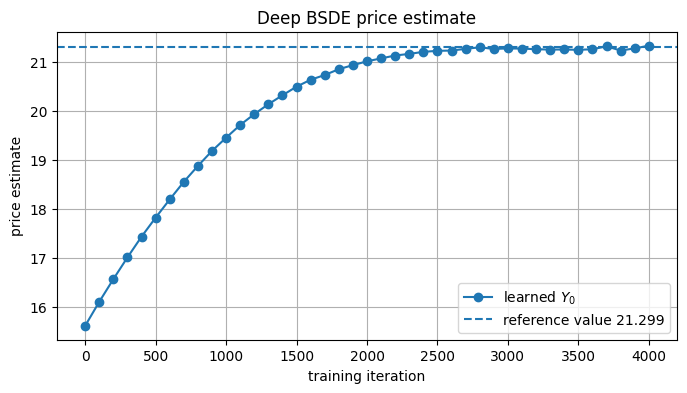

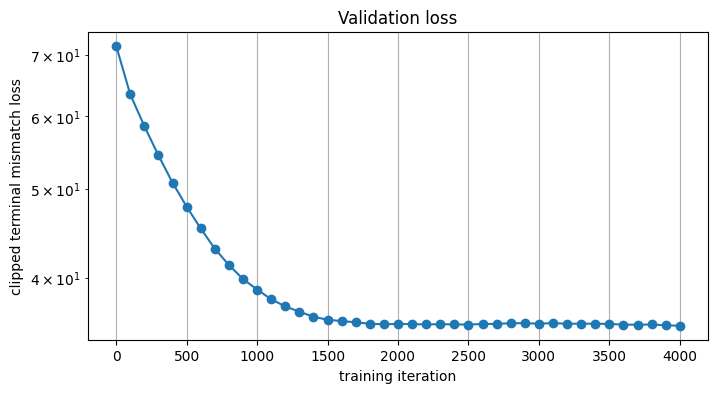

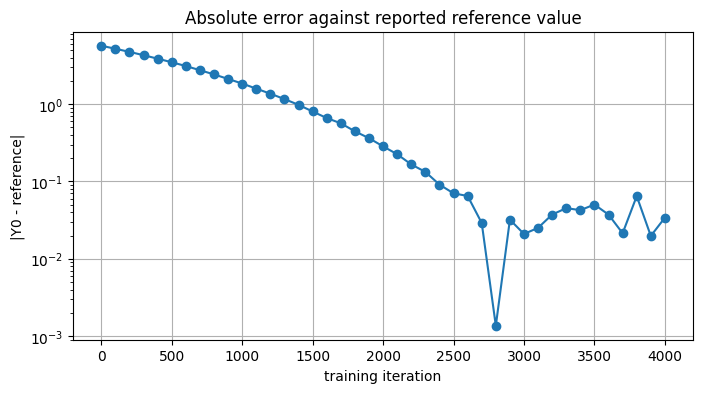

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history["iteration"], history["price"], marker="o", label="learned $Y_0$")
plt.axhline(REFERENCE_VALUE, linestyle="--", label="reference value 21.299")
plt.xlabel("training iteration")
plt.ylabel("price estimate")
plt.title("Deep BSDE price estimate")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.semilogy(history["iteration"], history["valid_loss"], marker="o")
plt.xlabel("training iteration")
plt.ylabel("clipped terminal mismatch loss")
plt.title("Validation loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.semilogy(history["iteration"], history["error"], marker="o")
plt.xlabel("training iteration")
plt.ylabel("|Y0 - reference|")
plt.title("Absolute error against reported reference value")
plt.grid(True)
plt.show()
